# Assignment 1 



Put this notebook in the same folder as:

- `support.py`
- `dataset_a1.txt`


In [ ]:
import random

import time

import numpy as np
import matplotlib.pyplot as plt

from deap import base, creator, tools, algorithms

import support


c:\Users\ozdep\Documents\Decision Making With AI\Assignment_1\.venv\Scripts\python.exe


## GA parameters

These are the initial parameter values for Task 1. 

In [2]:
POPULATION_SIZE = 80
N_GENERATIONS = 45
CROSSOVER_PROBABILITY = 0.8
MUTATION_PROBABILITY = 0.2
TOURNAMENT_SIZE = 3
PER_GENE_MUTATION_PROBABILITY = 0.05

RANDOM_SEED = 42

## Individual representation

A candidate Petri net is represented as a linearized matrix.

There are 12 transitions. Each transition has two numbers: start place and end place. Therefore, one individual has 12 * 2 = 24 integer values. Each integer is a place number from 0 to 8.

In [3]:
INDIVIDUAL_LENGTH = support.NR_TRANSITIONS * 2

LOWER_BOUND = 0
UPPER_BOUND = support.NR_PLACES - 1

print("Individual length:", INDIVIDUAL_LENGTH)
print("Allowed place values:", LOWER_BOUND, "to", UPPER_BOUND)

Individual length: 24
Allowed place values: 0 to 8


# Repair Function required for Task 4

In [4]:
def repair_individual(individual):
    mat = support.list_to_array(individual)

    # Loop through each transition and check the start and end places
    for i in range(support.NR_TRANSITIONS):
        start, end = mat[i]

        # Constraint 3: fix self-loops
        if start == end:
            options = [p for p in range(LOWER_BOUND, UPPER_BOUND + 1) if p != start]
            mat[i, 1] = random.choice(options)

        start, end = mat[i]

        # Constraint 5: fix backward transitions that are visible transitions
        if i >= 2 and end < start:
            options = [p for p in range(start, UPPER_BOUND + 1) if p != start]

            if options:
                mat[i, 1] = random.choice(options)
            else:
                # fallback if we're at the last place
                new_start = random.randint(LOWER_BOUND, UPPER_BOUND - 1)
                mat[i, 0] = new_start
                mat[i, 1] = random.randint(new_start + 1, UPPER_BOUND)

    individual[:] = mat.flatten().tolist()
    return individual

In [5]:
def repair_decorator(operator):
    def wrapper(*args, **kwargs):
        offspring = operator(*args, **kwargs)
        for ind in offspring:
            repair_individual(ind)
        return offspring
    return wrapper

## DEAP setup

In [6]:
if "FitnessMax_Task1" not in creator.__dict__:
    creator.create("FitnessMax_Task1", base.Fitness, weights=(1.0,))

if "Individual_Task1" not in creator.__dict__:
    creator.create("Individual_Task1", list, fitness=creator.FitnessMax_Task1)

toolbox = base.Toolbox()

# One gene is one place number from 0 to 8.
toolbox.register("attr_place", random.randint, LOWER_BOUND, UPPER_BOUND)

# One individual is a list of 24 place numbers.
toolbox.register(
    "individual",
    tools.initRepeat,
    creator.Individual_Task1,
    toolbox.attr_place,
    n=INDIVIDUAL_LENGTH,
)

# A population is a list of individuals.
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Fitness function from support.py.
toolbox.register("evaluate", support.fitness)

# Required operators for Task 1.
toolbox.register("mate", tools.cxTwoPoint)

toolbox.register(
    "mutate",
    tools.mutUniformInt,
    low=LOWER_BOUND,
    up=UPPER_BOUND,
    indpb=PER_GENE_MUTATION_PROBABILITY,
)

# Add decorators required for Task 4
toolbox.decorate("mate", repair_decorator)
toolbox.decorate("mutate", repair_decorator)

toolbox.register(
    "select",
    tools.selTournament,
    tournsize=TOURNAMENT_SIZE,
)

## Run the GA

In [18]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

population = toolbox.population(n=POPULATION_SIZE)
hall_of_fame = tools.HallOfFame(1)

stats = tools.Statistics(lambda individual: individual.fitness.values[0])
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)

start_time = time.time()

population, logbook = algorithms.eaSimple(
    population,
    toolbox,
    cxpb=CROSSOVER_PROBABILITY,
    mutpb=MUTATION_PROBABILITY,
    ngen=N_GENERATIONS,
    stats=stats,
    halloffame=hall_of_fame,
    verbose=True,
)

running_time = time.time() - start_time

gen	nevals	avg     	std    	min	max     
0  	80    	-9.45623	2.85587	-15	-2.73208
1  	67    	-6.8454 	2.3384 	-12	-2.66716
2  	65    	-5.64903	2.09618	-10	-0.75391
3  	73    	-4.16983	1.76436	-9 	0.377802
4  	57    	-3.06259	1.29542	-7 	0.0899158
5  	57    	-2.07254	1.2183 	-5 	0.346757 
6  	67    	-1.33251	0.962146	-4 	0.30509  
7  	66    	-0.77079	0.705668	-3 	0.332844 
8  	63    	-0.151697	0.516257	-1.91008	0.374511 
9  	63    	0.139876 	0.316317	-1      	0.424844 
10 	64    	0.13877  	0.540364	-2.7488 	0.383178 
11 	66    	0.245433 	0.401114	-1.832  	0.424844 
12 	60    	0.300387 	0.292071	-1.58038	0.498903 
13 	65    	0.26053  	0.520587	-3      	0.498903 
14 	69    	0.332974 	0.343467	-1.62549	0.498903 
15 	66    	0.243825 	0.553385	-1.91008	0.498903 
16 	69    	0.429493 	0.225366	-1.50068	0.498903 
17 	71    	0.344253 	0.633172	-4      	0.498903 
18 	69    	0.397074 	0.336387	-1.53026	0.498903 
19 	70    	0.308647 	0.605647	-3.54728	0.498903 
20 	71    	0.289834 	0.555768	-1.6332

## Results

In [19]:
best_individual = hall_of_fame[0]
best_fitness = best_individual.fitness.values[0]

print("Parameter values used:")
print("Population size:", POPULATION_SIZE)
print("Number of generations:", N_GENERATIONS)
print("Crossover probability:", CROSSOVER_PROBABILITY)
print("Mutation probability:", MUTATION_PROBABILITY)
print("Tournament size:", TOURNAMENT_SIZE)
print("Per-gene mutation probability:", PER_GENE_MUTATION_PROBABILITY)
print("Random seed:", RANDOM_SEED)

print("\nRunning time:", round(running_time, 2), "seconds")
print("Best fitness:", best_fitness)

print("\nBest individual:")
print(list(best_individual))

print("\nBest individual as matrix:")
print(support.list_to_array(best_individual))

Parameter values used:
Population size: 80
Number of generations: 45
Crossover probability: 0.8
Mutation probability: 0.2
Tournament size: 3
Per-gene mutation probability: 0.05
Random seed: 42

Running time: 117.58 seconds
Best fitness: 0.4989033189033186

Best individual:
[3, 4, 6, 8, 5, 6, 3, 4, 0, 7, 0, 5, 7, 8, 5, 8, 3, 5, 4, 6, 4, 8, 3, 6]

Best individual as matrix:
[[3 4]
 [6 8]
 [5 6]
 [3 4]
 [0 7]
 [0 5]
 [7 8]
 [5 8]
 [3 5]
 [4 6]
 [4 8]
 [3 6]]


## Plot best fitness at each generation

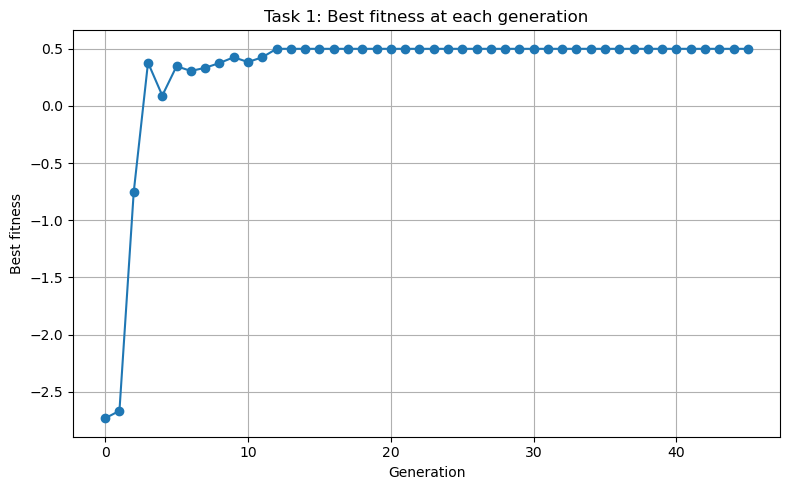

In [20]:
generations = logbook.select("gen")
best_fitness_per_generation = logbook.select("max")

plt.figure(figsize=(8, 5))
plt.plot(generations, best_fitness_per_generation, marker="o")
plt.xlabel("Generation")
plt.ylabel("Best fitness")
plt.title("Task 1: Best fitness at each generation")
plt.grid(True)
plt.tight_layout()
plt.savefig("task1_best_fitness.png", dpi=200)
plt.show()

In [9]:
N_RUNS = 10  

def run_variant(cx_op, mut_op, sel_op, n_runs=N_RUNS, seed_offset=0):

    best_fitnesses = []
    abf_curves = []

    start = time.time()

    for run in range(n_runs):
        random.seed(seed_offset + run)
        np.random.seed(seed_offset + run)

        tb = base.Toolbox()
        tb.register("attr_place", random.randint, LOWER_BOUND, UPPER_BOUND)
        tb.register(
            "individual", tools.initRepeat,
            creator.Individual_Task1, tb.attr_place, n=INDIVIDUAL_LENGTH,
        )
        tb.register("population", tools.initRepeat, list, tb.individual)
        tb.register("evaluate", support.fitness)
        tb.register("mate", cx_op)
        tb.register("mutate", mut_op, indpb=PER_GENE_MUTATION_PROBABILITY)
        if sel_op == tools.selTournament:
            tb.register("select", sel_op, tournsize=TOURNAMENT_SIZE)
        else:
            tb.register("select", sel_op)

        pop = tb.population(n=POPULATION_SIZE)
        hof = tools.HallOfFame(1)

        stats = tools.Statistics(lambda ind: ind.fitness.values[0])
        stats.register("max", np.max)

        pop, log = algorithms.eaSimple(
            pop, tb,
            cxpb=CROSSOVER_PROBABILITY,
            mutpb=MUTATION_PROBABILITY,
            ngen=N_GENERATIONS,
            stats=stats,
            halloffame=hof,
            verbose=False,
        )

        best_fitnesses.append(hof[0].fitness.values[0])
        abf_curves.append(log.select("max"))

    total_time = time.time() - start
    return best_fitnesses, abf_curves, total_time

In [13]:

variants = [
    # (label,               cx_op,            mut_op,                    sel_op)
    ("cxTwoPoint\nmutFlipBit\nselTournament",
        tools.cxTwoPoint,  tools.mutFlipBit,         tools.selTournament),
    ("cxTwoPoint\nmutFlipBit\nselRoulette",
        tools.cxTwoPoint,  tools.mutFlipBit,         tools.selRoulette),
    ("cxTwoPoint\nmutShuffleIndexes\nselTournament",
        tools.cxTwoPoint,  tools.mutShuffleIndexes,  tools.selTournament),
    ("cxTwoPoint\nmutShuffleIndexes\nselRoulette",
        tools.cxTwoPoint,  tools.mutShuffleIndexes,  tools.selRoulette),
    ("cxOrdered\nmutFlipBit\nselTournament",
        tools.cxOrdered,   tools.mutFlipBit,         tools.selTournament),
    ("cxOrdered\nmutFlipBit\nselRoulette",
        tools.cxOrdered,   tools.mutFlipBit,         tools.selRoulette),
    ("cxOrdered\nmutShuffleIndexes\nselTournament",
        tools.cxOrdered,   tools.mutShuffleIndexes,  tools.selTournament),
    ("cxOrdered\nmutShuffleIndexes\nselRoulette",
        tools.cxOrdered,   tools.mutShuffleIndexes,  tools.selRoulette),
]

results = {}  

for label, cx, mut, sel in variants:
    print(f"Running: {label.replace(chr(10), ' | ')} ...", end=" ", flush=True)
    bf, curves, t = run_variant(cx, mut, sel)
    results[label] = (bf, curves, t)
    abf = np.mean([c[-1] for c in curves])   
    print(f"ABF={abf:.4f}  time={t:.1f}s")

Running: cxTwoPoint | mutFlipBit | selTournament ... ABF=0.5935  time=1924.4s
Running: cxTwoPoint | mutFlipBit | selRoulette ... ABF=0.3668  time=2716.3s
Running: cxTwoPoint | mutShuffleIndexes | selTournament ... ABF=0.6535  time=1898.9s
Running: cxTwoPoint | mutShuffleIndexes | selRoulette ... ABF=0.3402  time=1395.2s
Running: cxOrdered | mutFlipBit | selTournament ... ABF=-0.3781  time=987.9s
Running: cxOrdered | mutFlipBit | selRoulette ... ABF=0.1695  time=1469.7s
Running: cxOrdered | mutShuffleIndexes | selTournament ... ABF=-0.1788  time=1107.9s
Running: cxOrdered | mutShuffleIndexes | selRoulette ... ABF=0.3455  time=1406.7s


In [14]:
print(f"\n{'Crossover':<18} {'Mutation':<22} {'Selection':<16} {'ABF':>8} {'Time(s)':>10}")
print("-" * 78)

for label, cx, mut, sel in variants:
    bf, curves, t = results[label]
    abf = np.mean([c[-1] for c in curves])
    cx_name, mut_name, sel_name = label.split("\n")
    print(f"{cx_name:<18} {mut_name:<22} {sel_name:<16} {abf:>8.4f} {t:>10.1f}")


Crossover          Mutation               Selection             ABF    Time(s)
------------------------------------------------------------------------------
cxTwoPoint         mutFlipBit             selTournament      0.5935     1924.4
cxTwoPoint         mutFlipBit             selRoulette        0.3668     2716.3
cxTwoPoint         mutShuffleIndexes      selTournament      0.6535     1898.9
cxTwoPoint         mutShuffleIndexes      selRoulette        0.3402     1395.2
cxOrdered          mutFlipBit             selTournament     -0.3781      987.9
cxOrdered          mutFlipBit             selRoulette        0.1695     1469.7
cxOrdered          mutShuffleIndexes      selTournament     -0.1788     1107.9
cxOrdered          mutShuffleIndexes      selRoulette        0.3455     1406.7


C:\Users\20210295\AppData\Local\Temp\ipykernel_33336\2804229213.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(all_best, labels=labels_short, patch_artist=True)


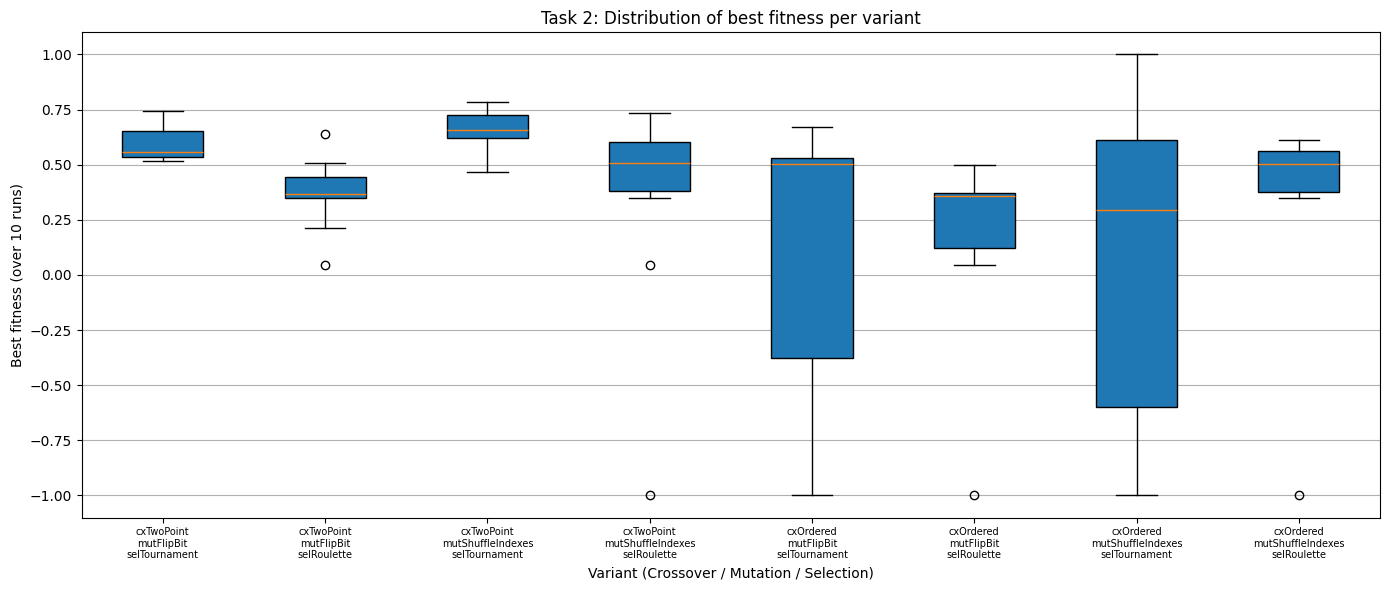

In [15]:
labels_short = [lbl.replace("\n", "\n") for lbl, *_ in variants]
all_best = [results[lbl][0] for lbl, *_ in variants]

fig, ax = plt.subplots(figsize=(14, 6))
ax.boxplot(all_best, labels=labels_short, patch_artist=True)
ax.set_xlabel("Variant (Crossover / Mutation / Selection)")
ax.set_ylabel("Best fitness (over 10 runs)")
ax.set_title("Task 2: Distribution of best fitness per variant")
ax.tick_params(axis="x", labelsize=7)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("task2_boxplots.png", dpi=200)
plt.show()

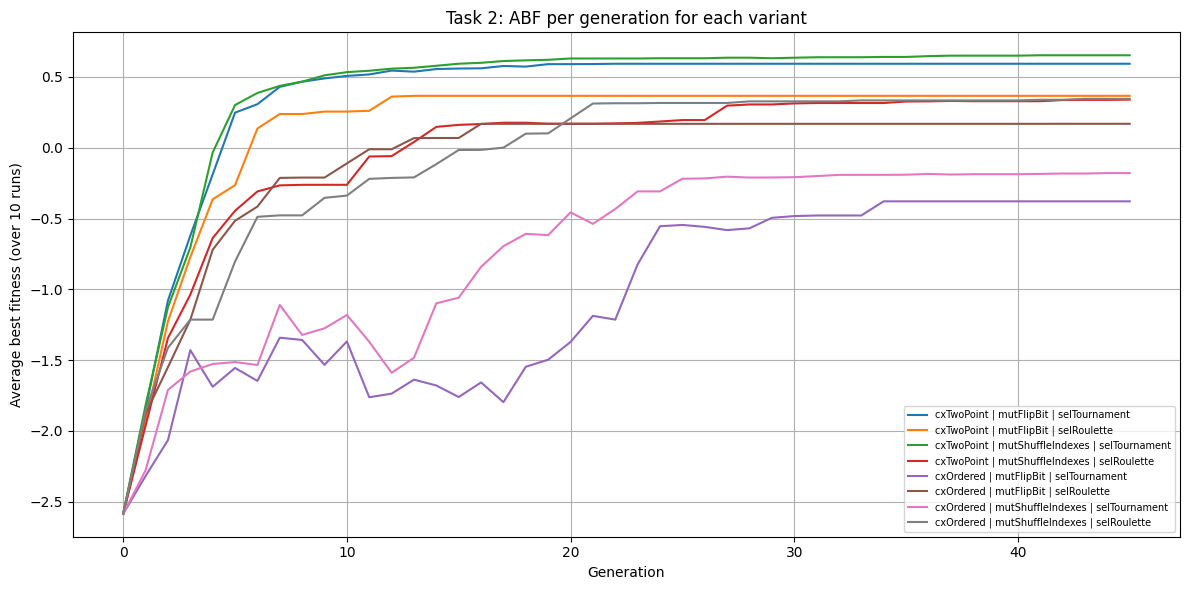

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

for label, *_ in variants:
    _, curves, _ = results[label]
    mean_curve = np.mean(curves, axis=0)
    ax.plot(range(N_GENERATIONS + 1), mean_curve, label=label.replace("\n", " | "))

ax.set_xlabel("Generation")
ax.set_ylabel("Average best fitness (over 10 runs)")
ax.set_title("Task 2: ABF per generation for each variant")
ax.legend(fontsize=7, loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("task2_abf_lines.png", dpi=200)
plt.show()

# Task 3: Impact of crossover and mutation probabilities

In [14]:
import itertools
import plotly.express as px
import pandas as pd

# We use the best operator combination from Task 2 to execute Task 3:
CX_OP = tools.cxTwoPoint
MUT_OP = tools.mutShuffleIndexes
SEL_OP = tools.selTournament
# Function to test the genetic algorithm with different hyperparameters
def test_hyperparameters(mut_prob : list, cx_prob : list):
    run_data = {}
    testing_params = list(itertools.product(mut_prob, cx_prob)) # Create list of tuples that contains combinations of mutation and crossover probabilties
    for mut, cx in testing_params:
        best_fitnesses = []
        abf_curves = []
        running_times = []
        print(f"Mutation probability: {mut} and Crossover probability: {cx}")
        for seed in range(N_RUNS):
            iter_time = time.time()
            random.seed(seed)
            np.random.seed(seed)
            # Create the toolbox
            tb = base.Toolbox()
            tb.register("attr_place", random.randint, LOWER_BOUND, UPPER_BOUND)
            tb.register(
                "individual", tools.initRepeat,
                creator.Individual_Task1, tb.attr_place, n=INDIVIDUAL_LENGTH,
            )
            tb.register("population", tools.initRepeat, list, tb.individual)
            tb.register("evaluate", support.fitness)
            tb.register("mate", CX_OP)
            tb.register("mutate", MUT_OP, indpb=PER_GENE_MUTATION_PROBABILITY)
            tb.register("select", SEL_OP, tournsize=TOURNAMENT_SIZE)
            pop = tb.population(n=POPULATION_SIZE)
            hof = tools.HallOfFame(1)

            stats = tools.Statistics(lambda ind: ind.fitness.values[0])
            stats.register("max", np.max)
            # Run the genetic algorithm with the given mutation and crossover probabilities
            pop, logbook = algorithms.eaSimple(
                pop,
                tb,
                cxpb=cx,
                mutpb=mut,
                ngen=N_GENERATIONS,
                stats=stats,
                halloffame=hof,
                verbose=False,
            )
            best_fitness = hof[0].fitness.values[0]
            best_fitnesses.append(best_fitness)
            abf_curves.append(logbook.select("max"))
            running_time = time.time() - iter_time
            running_times.append(running_time)
        run_data[(mut, cx, 'run_time')] = (best_fitnesses, abf_curves, running_times)
    return run_data




# Function to create the required plots from the results of the genetic algorithm with different hyperparameters
def boxplot_task3(results : pd.DataFrame):
    cx_values = sorted(set(cx for mut,cx, _ in results.keys()))
    mut_values = sorted(set(mut for mut, cx, _ in results.keys()))
    n_cx = len(cx_values)
    # Boxplot of ABF for each combination of mut and cx probabilities
    fig, axes = plt.subplots(1, n_cx, figsize=(5 * n_cx, 6), sharey=True)
    if n_cx == 1:
        axes = [axes]
    for ax, cx in zip(axes, cx_values):
        labels = [f"mut={mut}" for mut in mut_values]
        all_best = [results[(mut, cx, 'run_time')][0] for mut in mut_values]
        ax.boxplot(all_best, labels=labels, patch_artist=True)
        ax.set_title(f"Crossover Probability: {cx}")
        ax.set_xlabel("Mutation Probability")
        ax.set_ylabel("Best fitness (over 10 runs)")
        ax.grid(axis="y")
    fig.suptitle("Task 3: Distribution of best fitness for different mutation and crossover combinations", fontsize=16)
    plt.tight_layout()
    plt.show()
    return fig

def abf_lines_task3(results : pd.DataFrame):
    cx_values = sorted(set(cx for mut,cx, _ in results.keys()))
    mut_values = sorted(set(mut for mut, cx, _ in results.keys()))
    n_cx = len(cx_values)
    fig, axes = plt.subplots(1, n_cx, figsize=(5 * n_cx, 6), sharey=True)
    if n_cx == 1:
        axes = [axes]
    for ax, cx in zip(axes, cx_values):
        for mut in mut_values:
            _, curves, _ = results[(mut, cx, 'run_time')]
            mean_curve = np.mean(curves, axis=0)
            ax.plot(range(N_GENERATIONS + 1), mean_curve, label=f"mut={mut}")
        ax.set_title(f"Crossover Probability: {cx}")
        ax.set_xlabel("Generation")
        ax.set_ylabel("Average best fitness (over 10 runs)")
        ax.grid(True)
        ax.legend(fontsize=7, loc="lower right")
    fig.suptitle("Task 3: ABF per generation for each hyperparameter combination", fontsize=16)
    plt.tight_layout()
    plt.show()
    return fig



In [11]:
cx_prob_batch = [0.2, 0.4, 0.6, 0.8] # Crossover probabilities
mut_prob = [0.2, 0.4, 0.6, 0.8] # Mutation probabilities

results = test_hyperparameters(mut_prob, cx_prob_batch)
# Save to csv file
results_df = pd.DataFrame({
    "Mutation Probability": [mut for mut, cx, _ in results.keys()],
    "Crossover Probability": [cx for mut, cx, _ in results.keys()],
    "Best Fitnesses": [results[(mut, cx, 'run_time')][0] for mut, cx, _ in results.keys()],
    "ABF Curves": [results[(mut, cx, 'run_time')][1] for mut, cx, _ in results.keys()],
    "Running Times": [results[(mut, cx, 'run_time')][2] for mut, cx, _ in results.keys()],
})
results_df.to_csv("task3_results.csv", index=False)

Mutation probability: 0.2 and Crossover probability: 0.2
Mutation probability: 0.2 and Crossover probability: 0.4
Mutation probability: 0.2 and Crossover probability: 0.6
Mutation probability: 0.2 and Crossover probability: 0.8
Mutation probability: 0.4 and Crossover probability: 0.2
Mutation probability: 0.4 and Crossover probability: 0.4
Mutation probability: 0.4 and Crossover probability: 0.6
Mutation probability: 0.4 and Crossover probability: 0.8
Mutation probability: 0.6 and Crossover probability: 0.2
Mutation probability: 0.6 and Crossover probability: 0.4
Mutation probability: 0.6 and Crossover probability: 0.6
Mutation probability: 0.6 and Crossover probability: 0.8
Mutation probability: 0.8 and Crossover probability: 0.2
Mutation probability: 0.8 and Crossover probability: 0.4
Mutation probability: 0.8 and Crossover probability: 0.6
Mutation probability: 0.8 and Crossover probability: 0.8


In [12]:
print(f"\n{'Mutation Prob':<16} {'Crossover Prob':<16} {'ABF':>8} {'Time(s)':>10}")
print("-" * 54)

for (mut, cx, _), (best_fitnesses, curves, running_times) in results.items():
    abf = np.mean([c[-1] for c in curves])
    total_time = sum(running_times)
    print(f"{mut:<16} {cx:<16} {abf:>8.4f} {total_time:>10.1f}")


Mutation Prob    Crossover Prob        ABF    Time(s)
------------------------------------------------------
0.2              0.2                0.5509      621.4
0.2              0.4                0.5729      967.9
0.2              0.6                0.5844     1109.3
0.2              0.8                0.6535     1709.2
0.4              0.2                0.6295      928.4
0.4              0.4                0.6250     1185.0
0.4              0.6                0.6638     1242.1
0.4              0.8                0.6697     1258.4
0.6              0.2                0.5868      721.1
0.6              0.4                0.6253      791.4
0.6              0.6                0.6922      886.5
0.6              0.8                0.6919      975.2
0.8              0.2                0.6602      871.0
0.8              0.4                0.6630      870.7
0.8              0.6                0.6582      965.0
0.8              0.8                0.6381      956.6


C:\Users\dylan\AppData\Local\Temp\ipykernel_35860\1689615744.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(all_best, labels=labels, patch_artist=True)
C:\Users\dylan\AppData\Local\Temp\ipykernel_35860\1689615744.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(all_best, labels=labels, patch_artist=True)
C:\Users\dylan\AppData\Local\Temp\ipykernel_35860\1689615744.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(all_best, labels=labels, patch_artist=True)
C:\Users\dylan\AppData\Local\Temp\ipykernel_35860\1689615744.py:73: MatplotlibDeprecationWarning: The 'labels' paramet

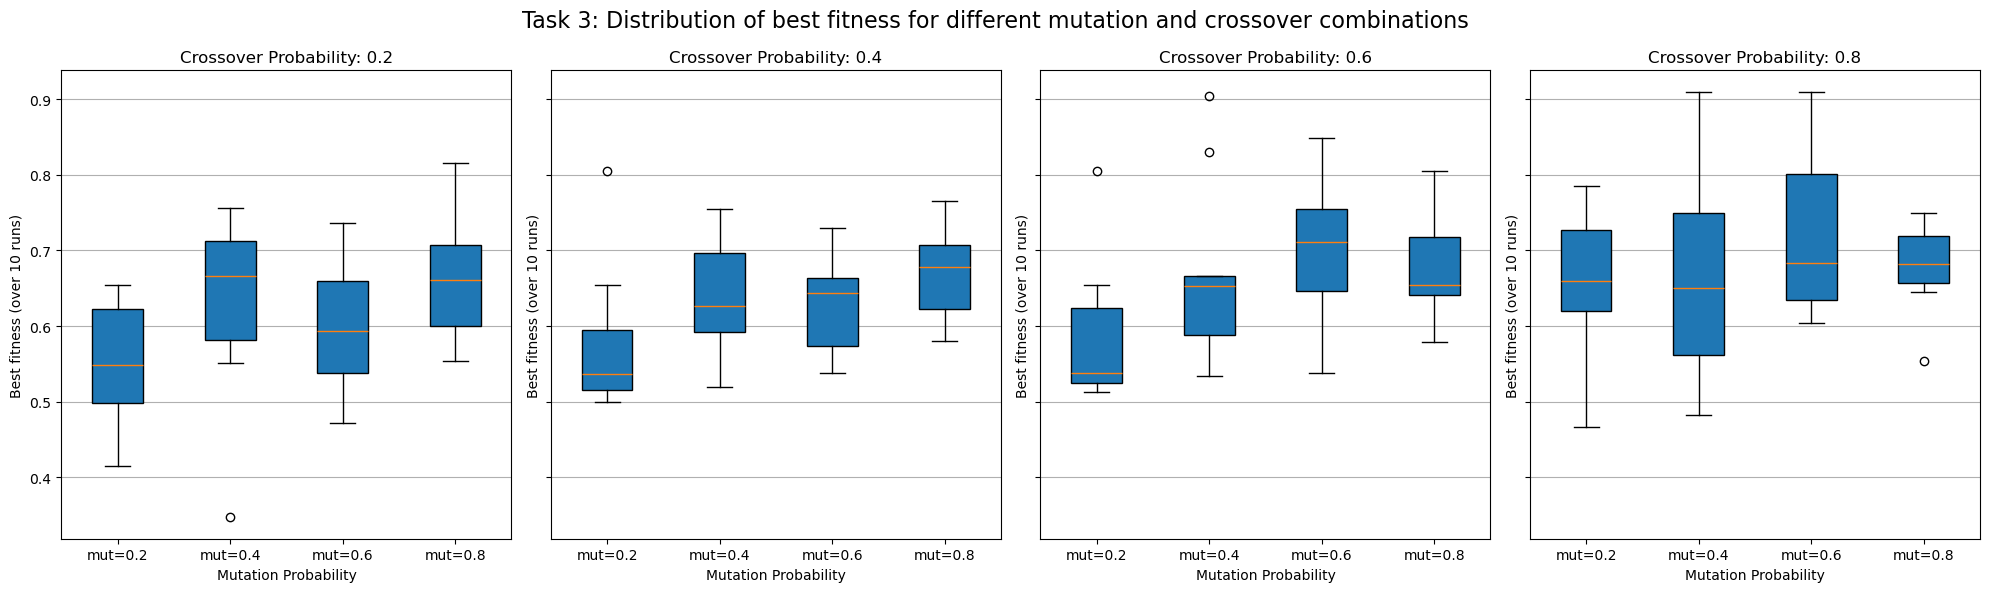

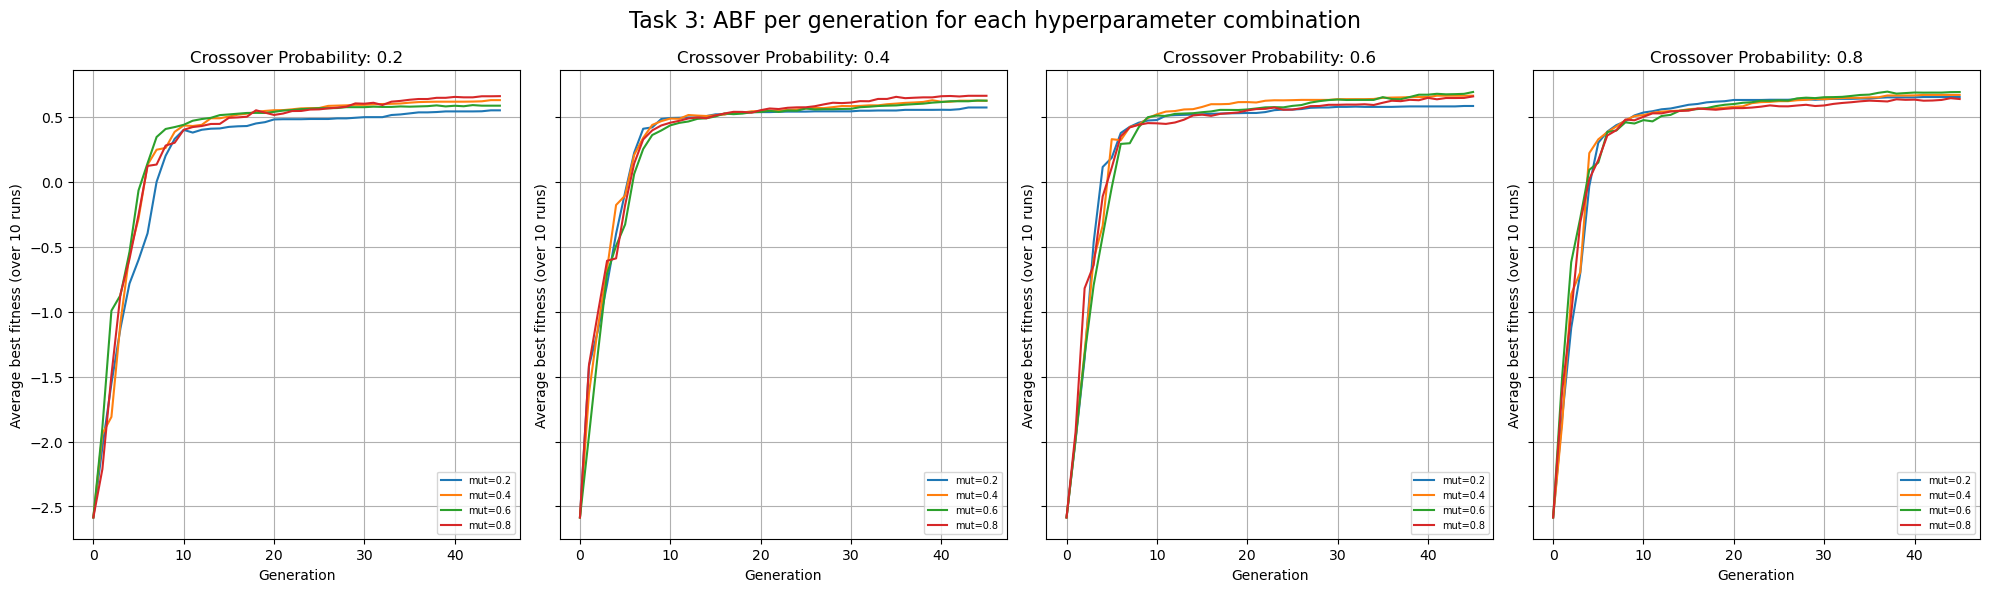

In [15]:
boxplot_1 = boxplot_task3(results)
boxplot_1.savefig("task3_boxplots.png", dpi=200)

abf_lines_1 = abf_lines_task3(results)
abf_lines_1.savefig("task3_abf_lines.png", dpi=200)

In [18]:
# From previous results, we saw that the best combination was 0.6 for both mutation and crossover probabilities.
# We will explore the values around 0.6 to see if we can find a better combination.
cx_prob_optimizing = [0.7, 0.8, 0.9]
mut_prob_optimizing = [0.5, 0.6, 0.7]
new_results = test_hyperparameters(mut_prob_optimizing, cx_prob_optimizing)

Mutation probability: 0.5 and Crossover probability: 0.7
Mutation probability: 0.5 and Crossover probability: 0.8
Mutation probability: 0.5 and Crossover probability: 0.9
Mutation probability: 0.6 and Crossover probability: 0.7
Mutation probability: 0.6 and Crossover probability: 0.8
Mutation probability: 0.6 and Crossover probability: 0.9
Mutation probability: 0.7 and Crossover probability: 0.7
Mutation probability: 0.7 and Crossover probability: 0.8
Mutation probability: 0.7 and Crossover probability: 0.9


In [19]:
new_results_df = pd.DataFrame({
    "Mutation Probability": [mut for mut, cx, _ in new_results.keys()],
    "Crossover Probability": [cx for mut, cx, _ in new_results.keys()],
    "Best Fitnesses": [new_results[(mut, cx, 'run_time')][0] for mut, cx, _ in new_results.keys()],
    "ABF Curves": [new_results[(mut, cx, 'run_time')][1] for mut, cx, _ in new_results.keys()],
    "Running Times": [new_results[(mut, cx, 'run_time')][2] for mut, cx, _ in new_results.keys()],
})
new_results_df.to_csv("task3_optimizing_results.csv", index=False)

In [20]:
print(f"\n{'Mutation Prob':<16} {'Crossover Prob':<16} {'ABF':>8} {'Time(s)':>10}")
print("-" * 54)

for (mut, cx, _), (best_fitnesses, curves, running_times) in new_results.items():
    abf = np.mean([c[-1] for c in curves])
    total_time = sum(running_times)
    print(f"{mut:<16} {cx:<16} {abf:>8.4f} {total_time:>10.1f}")


Mutation Prob    Crossover Prob        ABF    Time(s)
------------------------------------------------------
0.5              0.7                0.6110      849.2
0.5              0.8                0.7154      972.1
0.5              0.9                0.6483      994.6
0.6              0.7                0.7510      967.1
0.6              0.8                0.6919      929.2
0.6              0.9                0.6414      963.0
0.7              0.7                0.6968      953.0
0.7              0.8                0.6825      957.2
0.7              0.9                0.6732      995.3


C:\Users\dylan\AppData\Local\Temp\ipykernel_35860\1689615744.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(all_best, labels=labels, patch_artist=True)
C:\Users\dylan\AppData\Local\Temp\ipykernel_35860\1689615744.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(all_best, labels=labels, patch_artist=True)
C:\Users\dylan\AppData\Local\Temp\ipykernel_35860\1689615744.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(all_best, labels=labels, patch_artist=True)


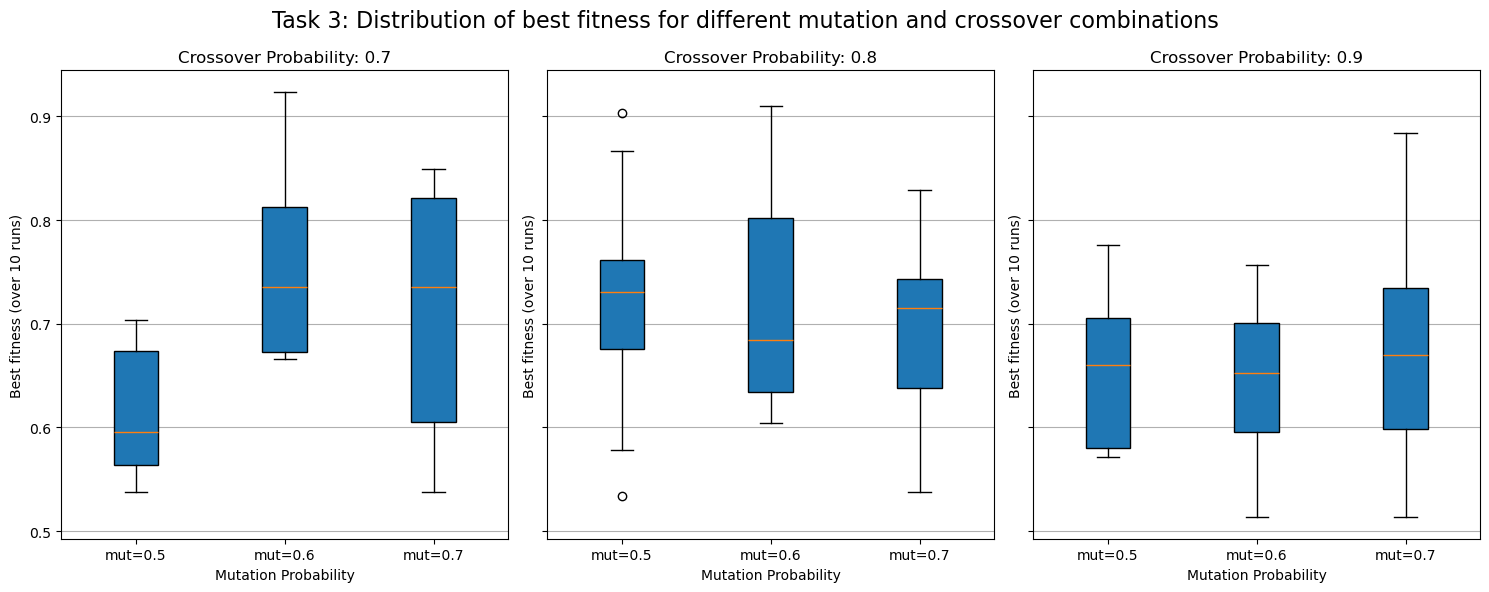

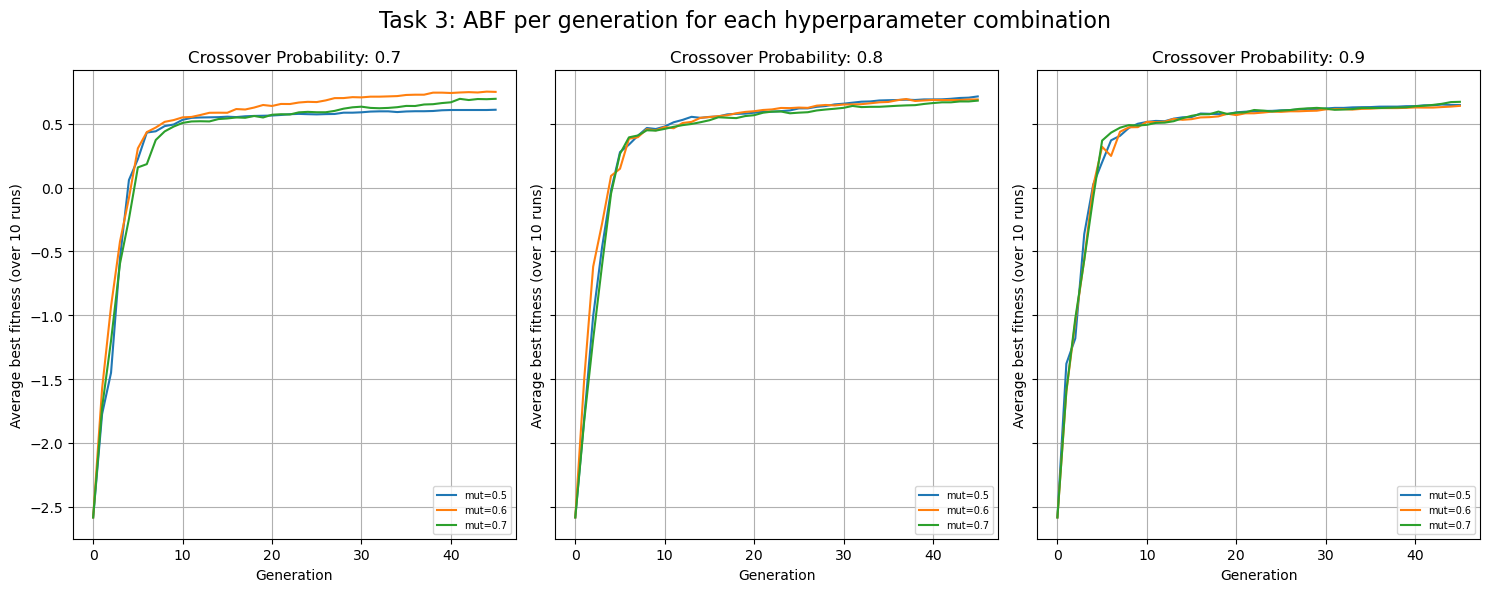

In [21]:
boxplot_1 = boxplot_task3(new_results)
boxplot_1.savefig("task3_optimizing_boxplots.png", dpi=200)

abf_lines_1 = abf_lines_task3(new_results)
abf_lines_1.savefig("task3_optimizing_abf_lines.png", dpi=200)

# Task 5: Final Experiment and Visualization

In [9]:
# Use best settings from task 2 and 3
CX_OP = tools.cxTwoPoint
MUT_OP = tools.mutShuffleIndexes
SEL_OP = tools.selTournament

CROSSOVER_PROBABILITY = 0.7
MUTATION_PROBABILITY = 0.6

In [10]:
# Helper function to run GA
def run_task5_ga(use_repair=False, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    tb = base.Toolbox()

    tb.register("attr_place", random.randint, LOWER_BOUND, UPPER_BOUND)

    tb.register(
        "individual",
        tools.initRepeat,
        creator.Individual_Task1,
        tb.attr_place,
        n=INDIVIDUAL_LENGTH,
    )

    tb.register("population", tools.initRepeat, list, tb.individual)
    tb.register("evaluate", support.fitness)

    tb.register("mate", CX_OP)
    tb.register("mutate", MUT_OP, indpb=PER_GENE_MUTATION_PROBABILITY)
    tb.register("select", SEL_OP, tournsize=TOURNAMENT_SIZE)

    if use_repair:
        tb.decorate("mate", repair_decorator)
        tb.decorate("mutate", repair_decorator)

    pop = tb.population(n=POPULATION_SIZE)
    hof = tools.HallOfFame(1)

    stats = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register("max", np.max)

    start = time.time()

    pop, log = algorithms.eaSimple(
        pop,
        tb,
        cxpb=CROSSOVER_PROBABILITY,
        mutpb=MUTATION_PROBABILITY,
        ngen=N_GENERATIONS,
        stats=stats,
        halloffame=hof,
        verbose=True,
    )

    runtime = time.time() - start

    return hof[0], hof[0].fitness.values[0], log, runtime

In [11]:
# Run without repair
best_without_repair, fitness_without_repair, log_without_repair, time_without_repair = run_task5_ga(
    use_repair=False,
    seed=42
)

print("Without repair")
print("Fitness:", fitness_without_repair)
print("Time:", round(time_without_repair, 2), "seconds")
print(support.list_to_array(best_without_repair))

gen	nevals	max     
0  	80    	-2.73208
1  	70    	-2.66716
2  	69    	-1.70572
3  	73    	-0.75391
4  	67    	-0.691618
5  	75    	0.269047 
6  	72    	0.366799 
7  	76    	0.366799 
8  	76    	0.366799 
9  	68    	0.436802 
10 	73    	0.436802 
11 	70    	0.436802 
12 	71    	0.436802 
13 	71    	0.48176  
14 	70    	0.48176  
15 	73    	0.48176  
16 	66    	0.513094 
17 	66    	0.553636 
18 	73    	0.553636 
19 	73    	0.574305 
20 	73    	0.574305 
21 	68    	0.574305 
22 	65    	0.574305 
23 	70    	0.574305 
24 	70    	0.574305 
25 	67    	0.574305 
26 	72    	0.574305 
27 	71    	0.574305 
28 	72    	0.622589 
29 	74    	0.623691 
30 	65    	0.623691 
31 	72    	0.614848 
32 	72    	0.614848 
33 	78    	0.614848 
34 	70    	0.614848 
35 	70    	0.614848 
36 	76    	0.614848 
37 	69    	0.614848 
38 	74    	0.614848 
39 	67    	0.614848 
40 	71    	0.614848 
41 	75    	0.614848 
42 	71    	0.614848 
43 	70    	0.614848 
44 	71    	0.614848 
45 	74    	0.635517 
Without repair
Fit

In [12]:
#Run with repair
best_with_repair, fitness_with_repair, log_with_repair, time_with_repair = run_task5_ga(
    use_repair=True,
    seed=42
)

print("With repair")
print("Fitness:", fitness_with_repair)
print("Time:", round(time_with_repair, 2), "seconds")
print(support.list_to_array(best_with_repair))

gen	nevals	max     
0  	80    	-2.73208
1  	75    	0.441676
2  	69    	0.513094
3  	65    	0.625093
4  	72    	0.564677
5  	71    	0.639284
6  	63    	0.639284
7  	69    	0.666272
8  	72    	0.666272
9  	71    	0.666272
10 	70    	0.685156
11 	75    	0.685156
12 	74    	0.703198
13 	70    	0.703198
14 	69    	0.685156
15 	69    	0.685156
16 	72    	0.685156
17 	67    	0.685156
18 	69    	0.703198
19 	70    	0.703198
20 	70    	0.704039
21 	70    	0.704039
22 	68    	0.704039
23 	74    	0.740124
24 	67    	0.740124
25 	73    	0.740124
26 	72    	0.740124
27 	68    	0.740124
28 	70    	0.740124
29 	70    	0.740124
30 	68    	0.740124
31 	71    	0.77705 
32 	70    	0.77705 
33 	67    	0.77705 
34 	70    	0.77705 
35 	73    	0.77705 
36 	70    	0.77705 
37 	65    	0.77705 
38 	71    	0.77705 
39 	68    	0.825556
40 	70    	0.88283 
41 	73    	0.825556
42 	71    	0.825556
43 	70    	0.77705 
44 	72    	0.77705 
45 	69    	0.77705 
With repair
Fitness: 0.8828304750804744
Time: 359.08 seconds

In [13]:
# Save Petri net PDFs
print(best_without_repair)
print(best_with_repair)

support.sol_to_graphviz(best_without_repair, "task5_without_repair.pdf")
support.sol_to_graphviz(best_with_repair, "task5_with_repair.pdf")

print("Saved:")
print("task5_without_repair.pdf")
print("task5_with_repair.pdf")

[6, 4, 6, 8, 4, 8, 0, 2, 2, 6, 6, 7, 0, 4, 4, 6, 4, 6, 2, 3, 4, 6, 4, 6]
[7, 5, 7, 6, 0, 6, 6, 7, 6, 7, 5, 7, 5, 7, 6, 7, 6, 7, 7, 8, 7, 8, 2, 5]
Saved:
task5_without_repair.pdf
task5_with_repair.pdf


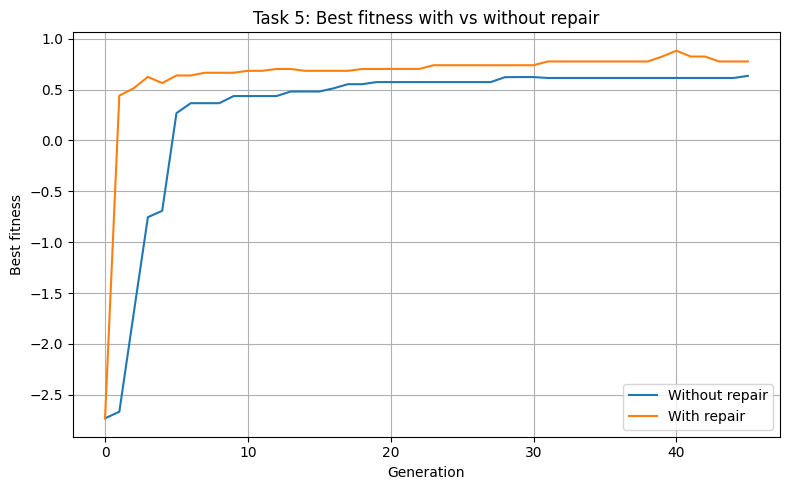

In [14]:
gen_without = log_without_repair.select("gen")
max_without = log_without_repair.select("max")

gen_with = log_with_repair.select("gen")
max_with = log_with_repair.select("max")

plt.figure(figsize=(8, 5))
plt.plot(gen_without, max_without, label="Without repair")
plt.plot(gen_with, max_with, label="With repair")
plt.xlabel("Generation")
plt.ylabel("Best fitness")
plt.title("Task 5: Best fitness with vs without repair")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("task5_fitness_comparison.png", dpi=200)
plt.show()